INFO:purepyindi2.transports:Connected to localhost:7624


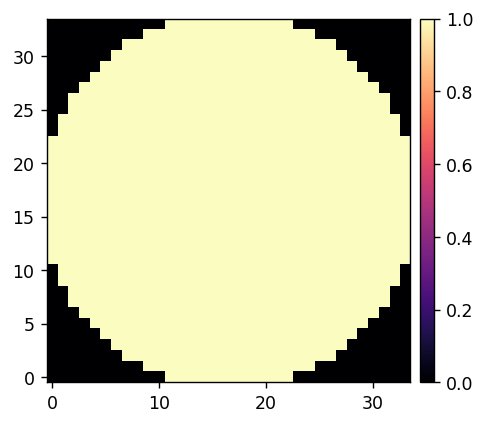

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime


import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize, CenteredNorm
from matplotlib.patches import Circle, Rectangle

import scoobscc


from scoobscc.math_module import xp, xcipy, ensure_np_array
from scoobscc import utils, telem, dm
from scoobscc import iefc
import scoobscc.scoob_interface as scoobi

import scoobpy


from magpyx.utils import ImageStream

import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient
client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

wavelength_c = 633e-9
camsci_pxscl = 4.6e-6
camsci_pxscl_lamDc = 0.307  

dm_mask = ensure_np_array(dm.make_mask(34))
utils.imshow([dm_mask])

%load_ext autoreload
%autoreload 2

## Experiment Directory

In [3]:
today = int(datetime.today().strftime('%Y%m%d'))
data_path = str(scoobscc.path)[:-9] + '/data_exp'

exp_path = data_path + f'/{today}_iefc_dig_mono'
telem.make_dir(exp_path)

Directory '/home/derbyk/src/scoob-scc/data_exp/20250710_iefc_dig_mono' created successfully.


## Init Camera
### Phase Retrieval Cam

In [182]:
camlo_channel = 'camlo'

xc, yc = (3700, 3630)
ncamsci = 256

scoobi.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camlo_channel, bin_mode=4)
time.sleep(1)
scoobi.set_cam_exp_time(1e-4, client0, cam_name=camlo_channel)
time.sleep(1)
scoobi.set_cam_gain(120, client0, cam_name=camlo_channel)
time.sleep(1)
scoobi.set_cam_blacklevel(4, client0, cam_name=camlo_channel)
time.sleep(1)

Set camlo ROI.
Set the camlo exposure time to 1.00e-04s
Set the camlo gain setting to 120.0
Set the camlo blacklevel to 4.0


In [194]:
scoobi.set_fib_atten(0, client)

Set the fiber attenuation to 0.0


### Science Cam

In [5]:
camsci_channel = 'camsci'
dm_ho_channel = 'dm00disp03'

xc, yc = (5680, 2615)
ncamsci = 256


scoobi.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_exp_time(1e-3, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_gain(120, client0, cam_name=camsci_channel)
time.sleep(1)
scoobi.set_cam_blacklevel(4, client0, cam_name=camsci_channel)
time.sleep(1)

camsci_stream = ImageStream(camsci_channel)
dm_ho_stream = ImageStream(dm_ho_channel)

Set camsci ROI.
Set the camsci exposure time to 1.00e-03s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 4.0


## Dark Frames
### Calibration

Move stagelinear to 40, 60 seems to introduce stray light.

In [8]:
scoobi.move_block_in(client0)

Set the camsci exposure time to 1.00e-04s
{'texp': 9.99999974737875e-05, 'gain': 120.0, 'atten': 0.0}


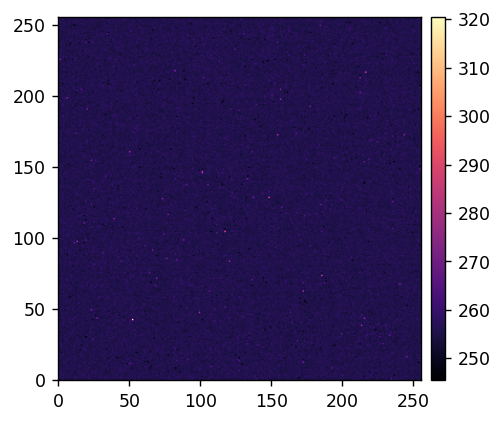

In [9]:
texp = 1e-4

scoobi.set_cam_exp_time(texp, client0, cam_name=camsci_channel)
time.sleep(3)

dark_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
dark_params.update({'atten':0.0})
dark_frame = scoobi.snap(camsci_stream, 100)

print(dark_params)
utils.imshow([dark_frame])

hdu = fits.PrimaryHDU(data=dark_frame)
hdr = hdu.header
hdr['TEXP'] = dark_params['texp']
hdr['GAIN'] = dark_params['gain']
hdr['ATTEN'] = dark_params['atten']

hdu.writeto(exp_path + f'/dark_frame_{texp:.0e}s.fits', overwrite=True)

In [8]:
scoobi.move_block_out(client0)

### Load for Use

In [10]:
dark_100ms = utils.load_fits(exp_path + '/dark_frame_1e-01s.fits')
dark_10ms = utils.load_fits(exp_path + '/dark_frame_1e-02s.fits')
dark_1ms = utils.load_fits(exp_path + '/dark_frame_1e-03s.fits')
dark_100us = utils.load_fits(exp_path + '/dark_frame_1e-04s.fits')

## Move PSF

In [11]:
scoobi.set_cam_exp_time(1e-3, client0, cam_name=camsci_channel)

Set the camsci exposure time to 1.00e-03s


In [58]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_x_pos', val=-2)

In [52]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagepupil_y_pos', val=-2)

## Get Reference PSF

In [40]:
scoobi.set_fib_atten(35, client)

Set the fiber attenuation to 35.0


{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 35.0, 'Iref': 25055.94}


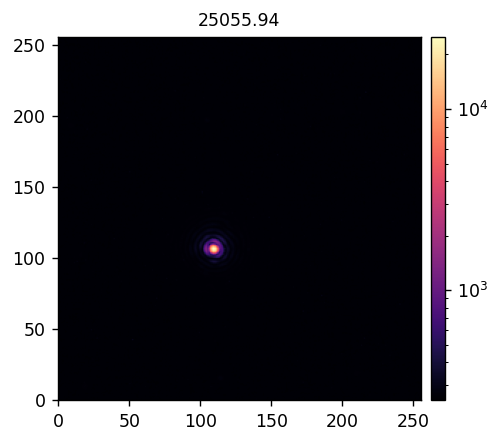

In [41]:
ref_psf = scoobi.snap(camsci_stream, 200)
Iref = np.max(ref_psf)

ref_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
ref_params.update({'atten':35.0})
ref_params.update({'Iref': Iref})

print(ref_params)
utils.imshow([ref_psf], titles=[f'{Iref:.2f}'], norms=[LogNorm()])

In [42]:
hdu = fits.PrimaryHDU(data=ref_psf)
hdr = hdu.header
hdr['TEXP'] = ref_params['texp']
hdr['GAIN'] = ref_params['gain']
hdr['ATTEN'] = ref_params['atten']

hdu.writeto(exp_path + '/ref_psf.fits', overwrite=True)

scoobi.set_fib_atten(0, client)

Set the fiber attenuation to 0.0


## Set Control Region

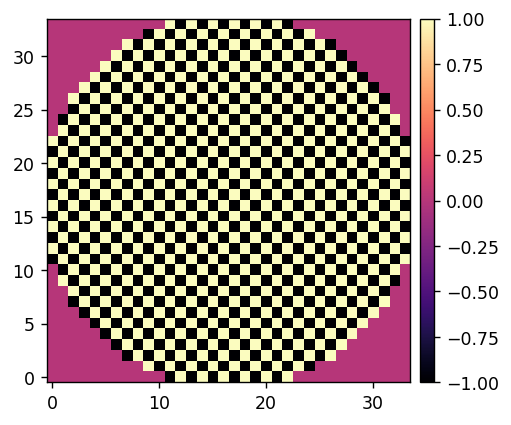

In [59]:
waffle_command = ensure_np_array(dm.make_fourier_command(x_cpa=17, y_cpa=17)) * dm_mask
utils.imshow([waffle_command])

{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 0.0}


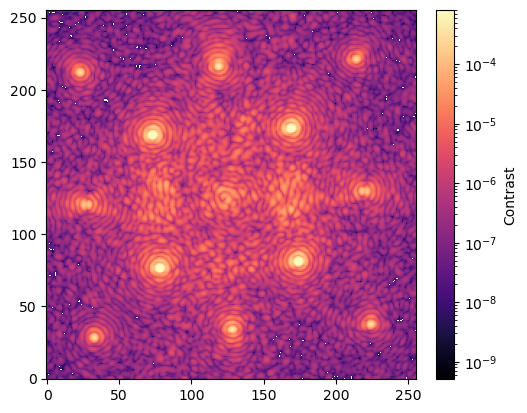

In [60]:
im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})

scoobi.set_dm(dm_ho_stream, 50e-9 * waffle_command)
waffle_im = scoobi.snap(camsci_stream, 100, ensure_np_array(dark_1ms), im_params, ref_params)

print(im_params)
plt.figure()
plt.imshow(waffle_im, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')

Centroids:
 [[ 78.25443725  76.37047813]
 [ 73.30065118 168.42072175]
 [169.29906168 173.04509349]
 [174.30529356  81.01783269]
 [ 78.25443725  76.37047813]]


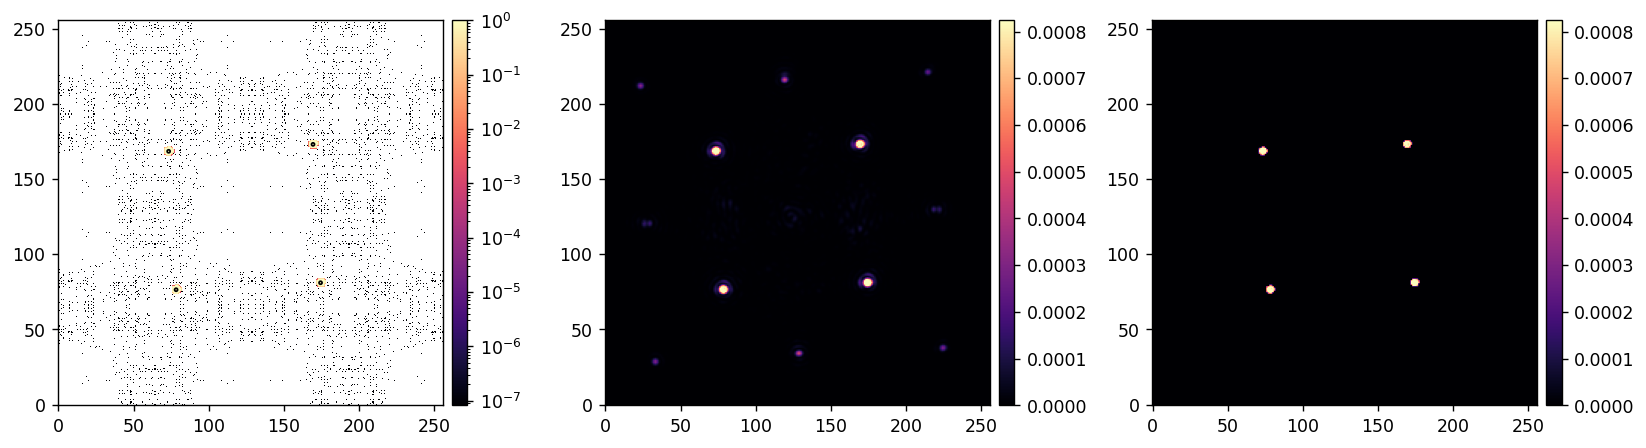

Angle:  87.06945177911632
Measured center in X:  123.79448685335781
Measured center in Y:  124.72662003416683
Required shift in X:  4.0
Required shift in Y:  3.0


In [61]:
scoobi.zero_dm(dm_ho_stream)

xshift, yshift, angle = utils.measure_waffle_center_and_angle(
    xp.array(waffle_im), 
    camsci_pxscl_lamDc, 
    im_thresh=5e-4, 
    r_thresh_min=16,
    r_thresh_max=25,
)

In [62]:
iwa = 3
owa = 10
rotation = angle - 90

control_mask = ensure_np_array( utils.create_annular_mask(
    ncamsci, 
    camsci_pxscl_lamDc,
    iwa, 
    owa, 
    edge=iwa, 
    x_shift=-xshift,
    y_shift=-yshift,
    rotation=rotation,
))

## Get Starting Coro Image

Make sure stagepiezo is at -1000

In [52]:
scoobpy.utils.move_relative(client=client, device='stagepiezo.stagefold_pos', val=-5000)

{'texp': 0.00100000004749745, 'gain': 120.0, 'atten': 0.0}


Text(0.5, 0.98, 'Control Region Contrast: 3.19e-06')

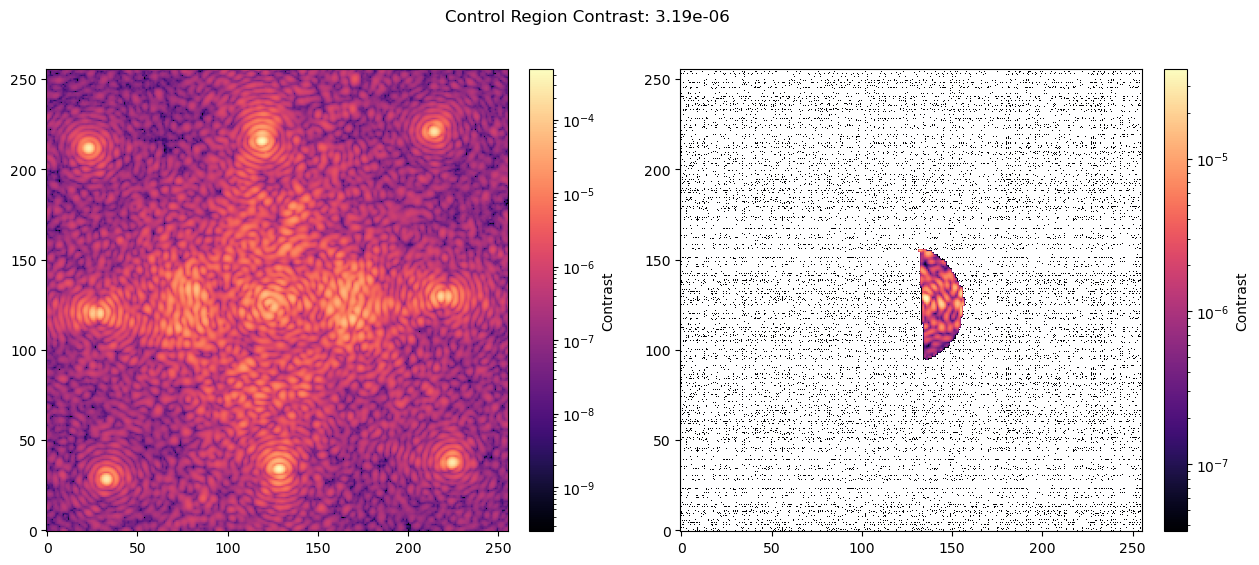

In [63]:
scoobi.zero_dm(dm_ho_stream)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})

im_unmod = scoobi.snap(camsci_stream, 200, ensure_np_array(dark_1ms), im_params, ref_params)
im_unmod[im_unmod < 0] = 0

print(im_params)
plt.figure(figsize=(15, 6))
plt.subplot(121)
plt.imshow(im_unmod, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.subplot(122)
plt.imshow(im_unmod * control_mask, norm='log', cmap='magma')
plt.colorbar(fraction=0.046, pad=0.04, label='Contrast')
plt.suptitle(f'Control Region Contrast: {np.mean(im_unmod[control_mask]):.2e}')

## Create Probe/Calibration Modes

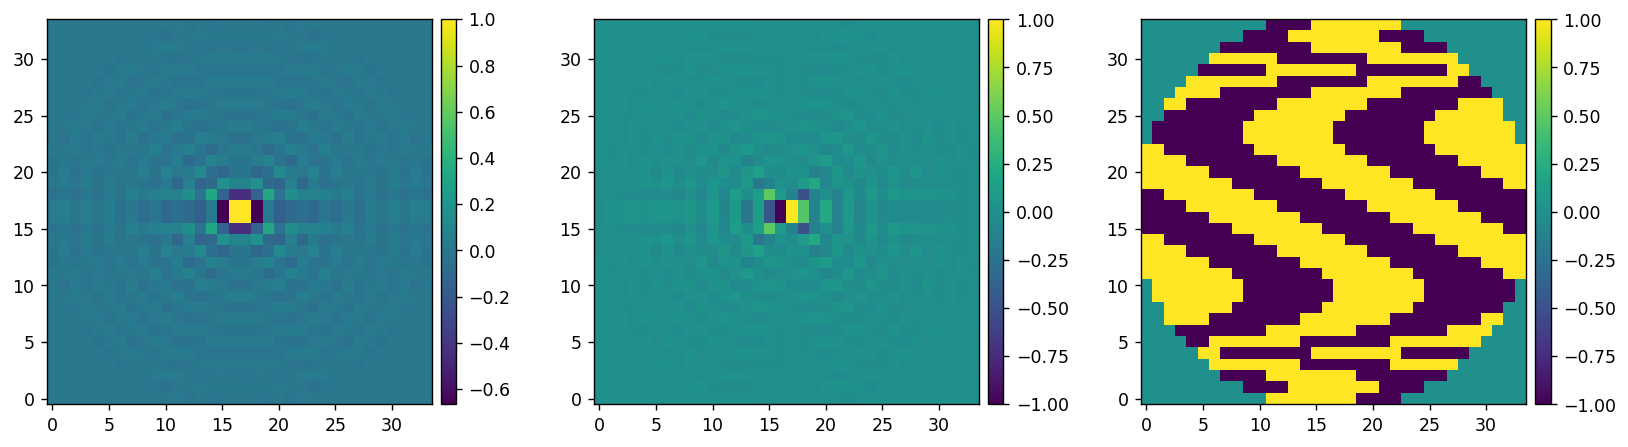

In [64]:
reload(utils)
reload(dm)
probe_iwa = 2
probe_owa = 15

fourier_probes = ensure_np_array(dm.create_fourier_probes(
    xp.array(dm_mask), 
    ncamsci,
    camsci_pxscl_lamDc,
    probe_iwa,
    probe_owa,
    # edge=probe_iwa,
    fourier_sampling=0.75, 
    # rotation=90,
    nprobes=2,
    # plot=True,
    use_weighting=True,
))

calib_modes = ensure_np_array( dm.create_hadamard_modes(xp.array(dm_mask)) ) 
modal_matrix = calib_modes.reshape(calib_modes.shape[0], -1).T

utils.imshow([fourier_probes[0], fourier_probes[1], calib_modes[8]], cmaps=3*['viridis'])

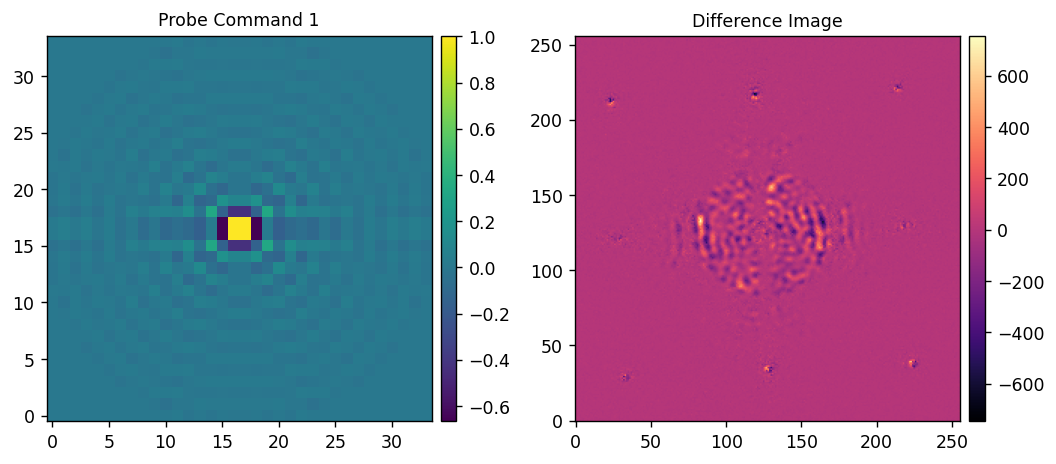

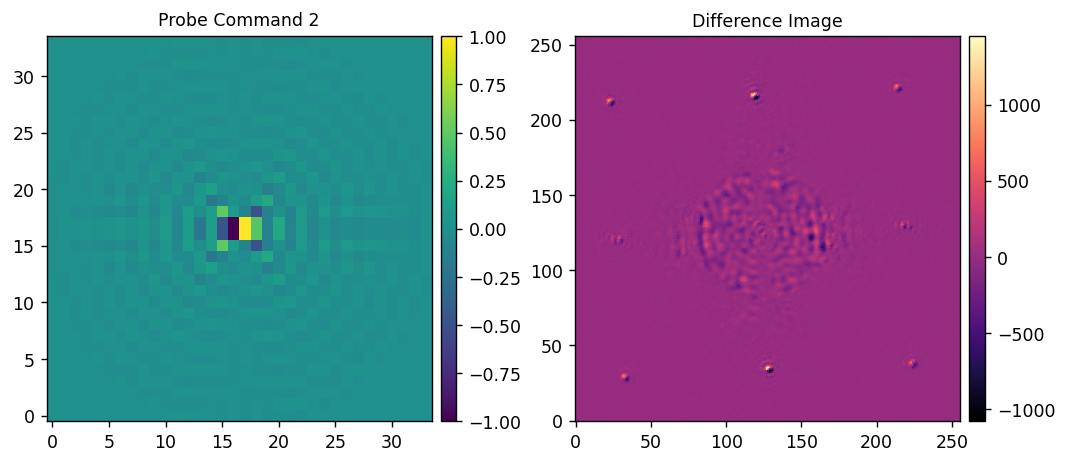

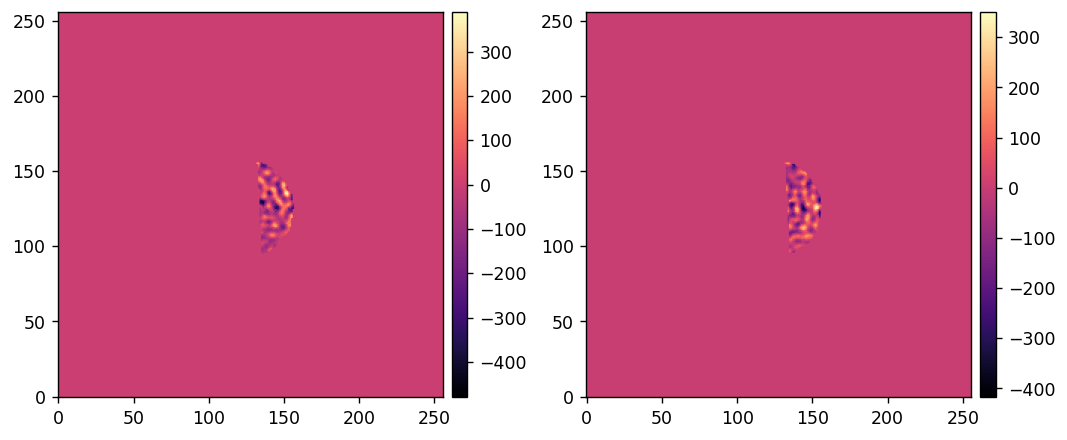

In [65]:
reload(iefc)
scoobi.zero_dm(dm_ho_stream)

diff_ims = iefc.take_measurement(
    camsci_stream, 
    dm_ho_stream, 
    im_params,
    ref_params,
    fourier_probes,
    probe_amplitude=3e-9,
    NFRAMES=25,
    plot=True, 
)
diff_ims *= control_mask
utils.imshow([diff_ims[0], diff_ims[1]])

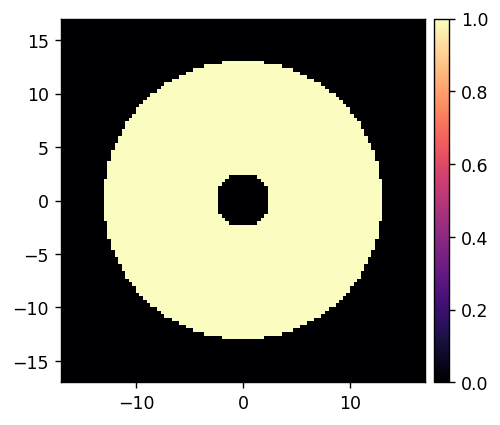

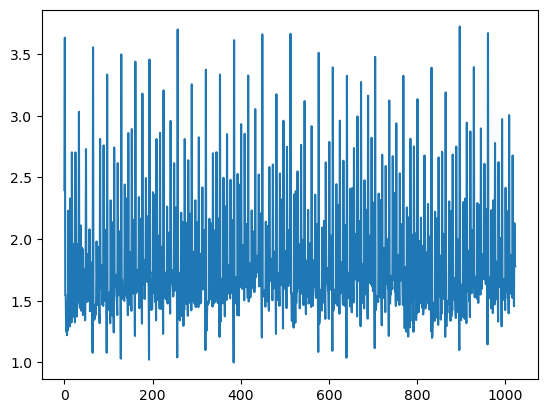

In [66]:
scale_factors = iefc.compute_hadamard_scale_factors(xp.array(calib_modes), scale_exp=1/5, scale_thresh=4, oversamp=3, plot=True)

## Calibrate Jacobian

In [149]:
scoobi.set_cam_exp_time(1e-2, client0, cam_name=camsci_channel)
time.sleep(3)

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})

Set the camsci exposure time to 1.00e-02s


Calibrating iEFC...
	Calibrated mode 1024/1024 in 1809.293s
Calibration complete.


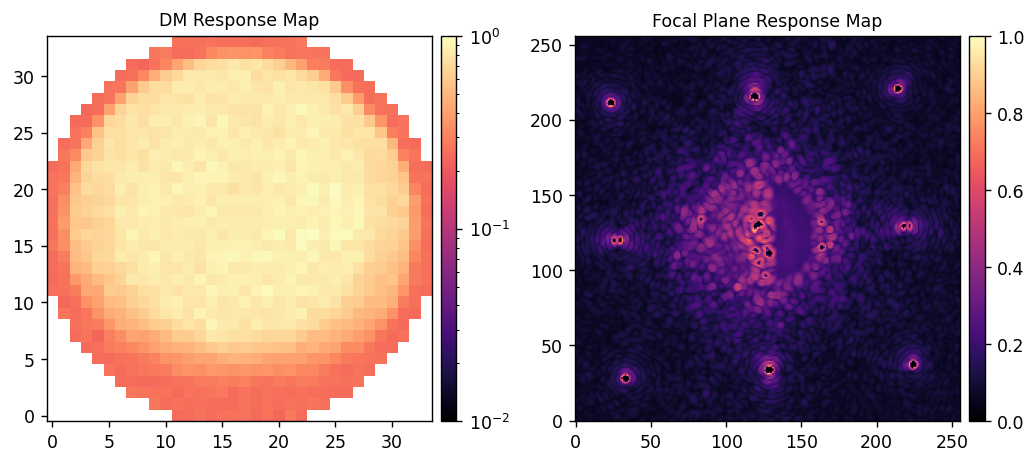

In [150]:
# scoobi.zero_dm(dm_ho_stream)

probe_amp = 2.5e-9
calib_amp = 2.5e-9
NFRAMES = 20

probe_amp = 1e-9
calib_amp = 1e-9
NFRAMES = 10

response_matrix, response_cube = iefc.calibrate(
    camsci_stream, 
    dm_ho_stream, 
    control_mask, 
    probe_amp, 
    fourier_probes, 
    calib_amp, 
    calib_modes[:],
    im_params,
    ref_params,
    NFRAMES=NFRAMES,
    delay=0.1,
    scale_factors=scale_factors, 
    plot_responses=True, 
)

In [75]:
iefc_calib_data = {
    'response_matrix':response_matrix,
    'response_cube':response_cube,
    'control_mask':control_mask,
    'NFRAMES':NFRAMES,
    'probe_amp':probe_amp,
    'probe_modes':fourier_probes,
    'calib_amp':calib_amp,
    'scale_factors':scale_factors,
}
utils.save_pickle(exp_path + '/iefc_calib.pkl', iefc_calib_data)

Saved data to:  /home/derbyk/src/scoob-scc/data_exp/20250710_iefc_dig_mono/iefc_calib.pkl


In [151]:
cm25 = utils.beta_reg(response_matrix, -2.5, return_np=1)
cm50 = utils.beta_reg(response_matrix, -5, return_np=1)
cm60 = utils.beta_reg(response_matrix, -6, return_np=1)

Set the camsci exposure time to 1.00e-03s
2.9935513608921605e-06


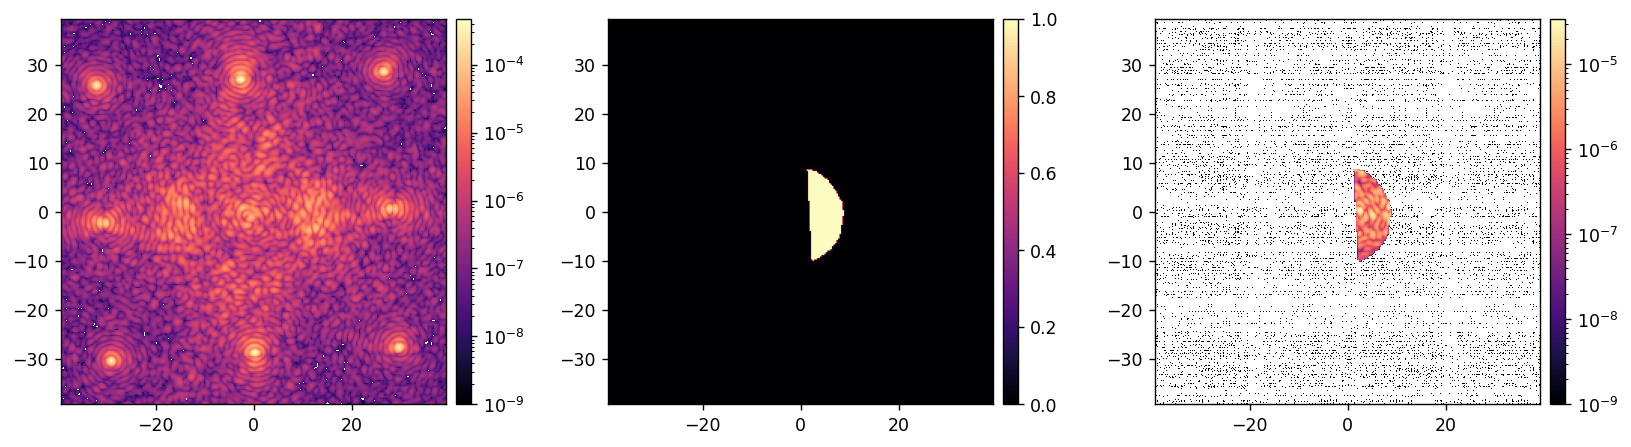

In [92]:
scoobi.set_cam_exp_time(1e-3, client0, cam_name=camsci_channel)
scoobi.zero_dm(dm_ho_stream)

ref_coro_im = scoobi.snap(camsci_stream, 100, ensure_np_array(dark_1ms), im_params, ref_params)
ref_contrast = np.mean(ref_coro_im[control_mask])
print(ref_contrast)
utils.imshow(
    [ref_coro_im, control_mask, control_mask * ref_coro_im],
    norms=[LogNorm(1e-9), None, LogNorm(1e-9)],
    pxscls=[camsci_pxscl_lamDc]*3,
    cmaps=['magma']*3,)

In [122]:
scoobi.zero_dm(dm_ho_stream)

iefc_data = {
    'images':[ref_coro_im],
    'contrasts':[ref_contrast],
    'commands':[],
    'del_commands':[],
    'pixelscale':camsci_pxscl_lamDc,
    'control_mask':control_mask, 
    'probes':fourier_probes,
}

In [152]:
scoobi.set_cam_exp_time(1e-1, client0, cam_name=camsci_channel)
time.sleep(3)
dark = dark_100ms

im_params = scoobi.get_im_params(client0, client, cam_name=camsci_channel)
im_params.update({'atten':0.0})

Set the camsci exposure time to 1.00e-01s


Running iteration 48 / 50
Measuring dark hole state ...


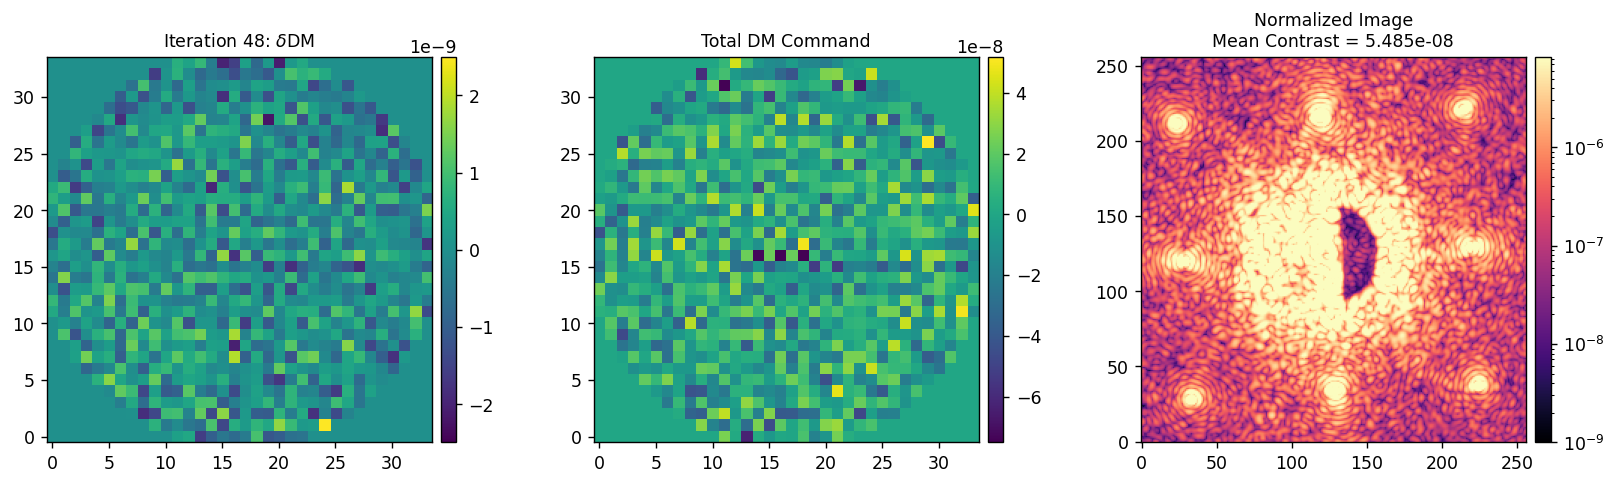

Running iteration 49 / 50
Measuring dark hole state ...


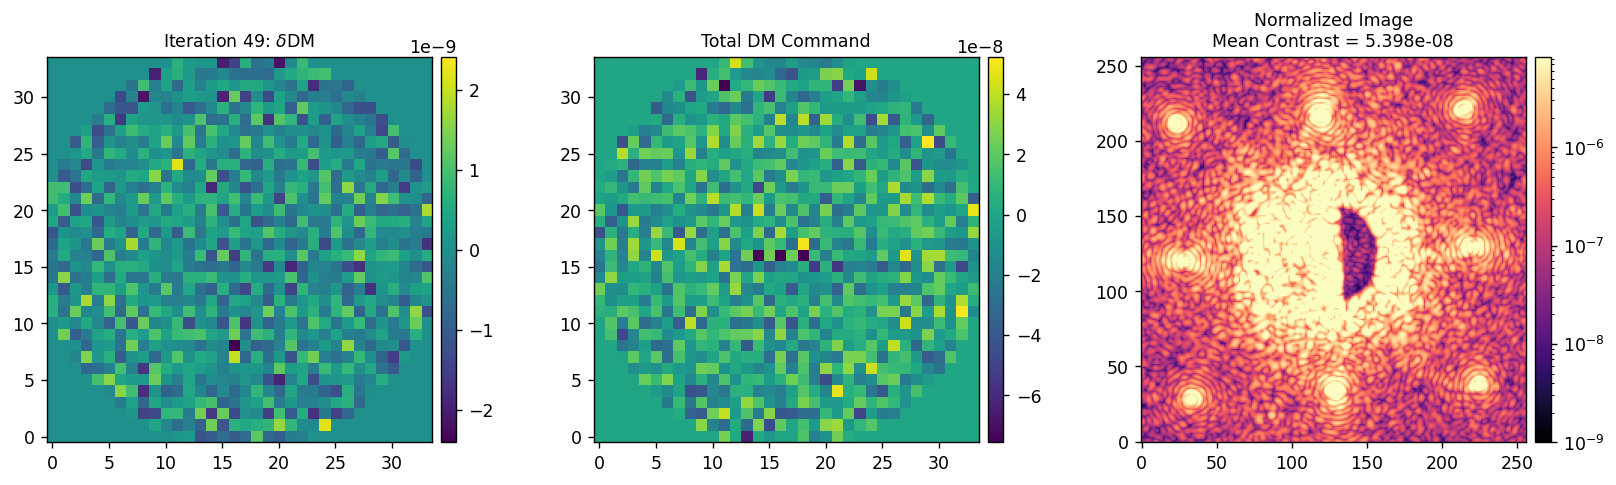

Running iteration 50 / 50
Measuring dark hole state ...


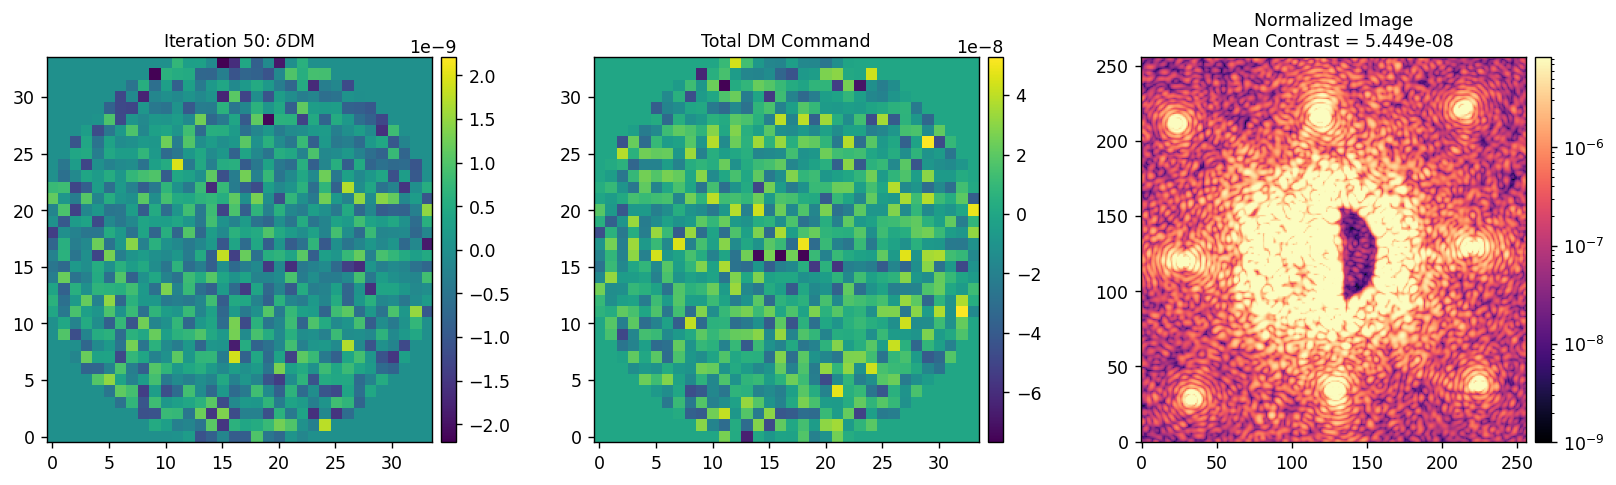

Completed 3 iterations in 24.426s.


In [159]:
probe_amp = 5e-9
probe_amp = 4e-9
probe_amp = 3e-9
probe_amp = 2.5e-9
probe_amp = 2e-9
# probe_amp = 1.5e-9
# probe_amp = 1e-9
# probe_amp = 0.75e-9
# probe_amp = 0.5e-9
# probe_amp = 0.25e-9

NFRAMES = 15

iefc_data = iefc.run(
    iefc_data, 
    camsci_stream,
    dm_ho_stream,
    cm25,
    # cm50,
    # cm60,
    probe_amp, 
    fourier_probes, 
    modal_matrix,
    control_mask,
    im_params,
    ref_params, 
    ensure_np_array(dark), 
    NFRAMES=NFRAMES, 
    delay=0.01,
    num_iterations=3,
    gain=0.75, 
    leakage=0.0,
    plot_current=True,
    plot_all=True,
    vmin=1e-9,
)

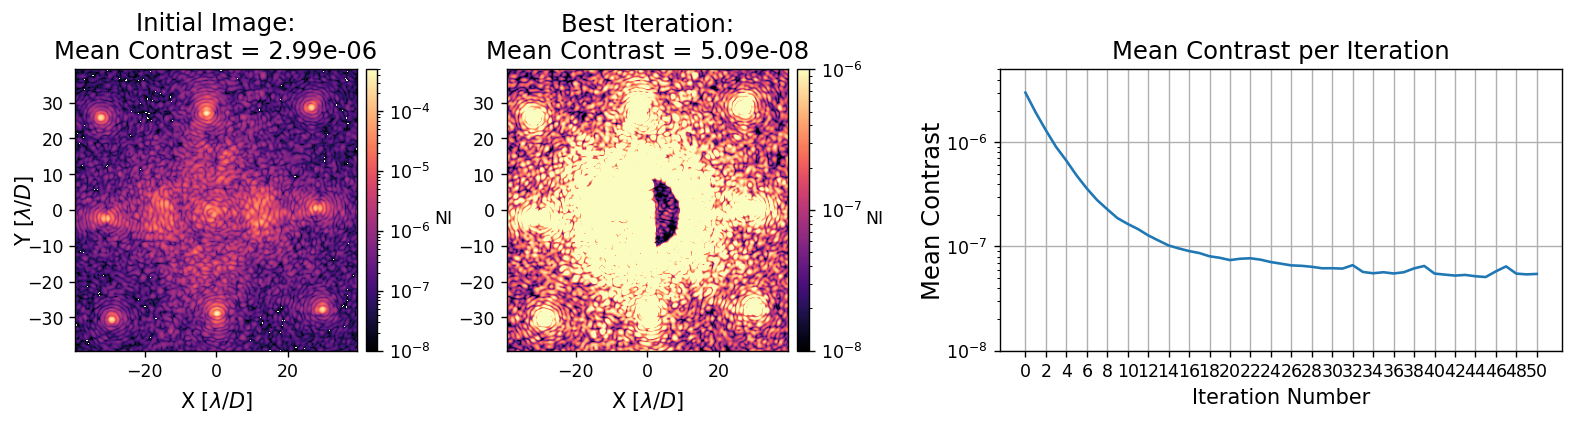

In [160]:
iefc.plot_data_with_ref(
    iefc_data,
    im1vmin=1e-8, im1vmax=5e-4,
    im2vmin=1e-8, im2vmax=1e-6, 
    vmin=1e-8, vmax=5e-6,
)

In [120]:
utils.save_pickle(exp_path + '/dig01.pkl', iefc_data)

Saved data to:  /home/derbyk/src/scoob-scc/data_exp/20250710_iefc_dig_mono/dig01.pkl


In [144]:
iefc_data = utils.load_pickle(exp_path + '/dig01.pkl')

In [145]:
scoobi.set_dm(dm_command=iefc_data['commands'][-1], dm_stream=dm_ho_stream)